In [1]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Code for Metric Score Calculations

In [2]:
def silhouette_score_modified(X, labels):

    X = np.asarray(X)
    labels = np.asarray(labels)

    n = len(X)
    unique_labels = np.unique(labels)

    # pairwise distance matrix
    D = cdist(X, X)

    # centroids
    centroids = {
        l: X[labels == l].mean(axis=0)
        for l in unique_labels
    }

    # distance to centroid
    dist_to_centroid = np.zeros(n)
    for i in range(n):
        d = np.linalg.norm(X[i] - centroids[labels[i]])
        dist_to_centroid[i] = d + 1e-8   # avoid zero

    silhouette_scores = np.zeros(n)

    for i in range(n):

        # a(i) 
        same_cluster = (labels == labels[i])
        same_cluster[i] = False  # exclude self

        if not np.any(same_cluster):
            silhouette_scores[i] = 0
            continue

        intra_dist = D[i, same_cluster]
        intra_weights = 1.0 / dist_to_centroid[same_cluster]

        a = np.sum(intra_dist * intra_weights) / np.sum(intra_weights)

        # b(i)
        b = np.inf

        for l in unique_labels:
            if l == labels[i]:
                continue

            mask = (labels == l)
            inter_dist = D[i, mask]
            inter_weights = 1.0 / dist_to_centroid[mask]

            b_l = np.sum(inter_dist * inter_weights) / np.sum(inter_weights)
            b = min(b, b_l)

        # silhouette score for i
        silhouette_scores[i] = (b - a) / max(a, b)

    return silhouette_scores.mean()

In [3]:
def silhouette_score_a_modified(X, labels):

    X = np.asarray(X)
    labels = np.asarray(labels)

    n = len(X)
    unique_labels = np.unique(labels)

    # pairwise distance matrix
    D = cdist(X, X)

    # centroids
    centroids = {
        l: X[labels == l].mean(axis=0)
        for l in unique_labels
    }

    # distance to centroid
    dist_to_centroid = np.zeros(n)
    for i in range(n):
        d = np.linalg.norm(X[i] - centroids[labels[i]])
        dist_to_centroid[i] = d + 1e-8   # avoid zero

    silhouette_scores = np.zeros(n)

    for i in range(n):

        # a(i) 
        same_cluster = (labels == labels[i])
        same_cluster[i] = False  # exclude self

        if not np.any(same_cluster):
            silhouette_scores[i] = 0
            continue

        intra_dist = D[i, same_cluster]
        intra_weights = 1.0 / dist_to_centroid[same_cluster]

        a = np.sum(intra_dist * intra_weights) / np.sum(intra_weights)

        # b(i)
        b = np.inf

        for l in unique_labels:
            if l == labels[i]:
                continue

            mask = (labels == l)
            inter_dist = D[i, mask]
            #inter_weights = 1.0 / dist_to_centroid[mask]

            b_l = np.sum(inter_dist) / len(inter_dist)
            b = min(b, b_l)

        # silhouette score for i
        silhouette_scores[i] = (b - a) / max(a, b)

    return silhouette_scores.mean()

In [4]:
def silhouette_score_b_modified(X, labels):

    X = np.asarray(X)
    labels = np.asarray(labels)

    n = len(X)
    unique_labels = np.unique(labels)

    # pairwise distance matrix
    D = cdist(X, X)

    # centroids
    centroids = {
        l: X[labels == l].mean(axis=0)
        for l in unique_labels
    }

    # distance to centroid
    dist_to_centroid = np.zeros(n)
    for i in range(n):
        d = np.linalg.norm(X[i] - centroids[labels[i]])
        dist_to_centroid[i] = d + 1e-8   # avoid zero

    silhouette_scores = np.zeros(n)

    for i in range(n):

        # a(i) 
        same_cluster = (labels == labels[i])
        same_cluster[i] = False  # exclude self

        if not np.any(same_cluster):
            silhouette_scores[i] = 0
            continue

        intra_dist = D[i, same_cluster]
        #intra_weights = 1.0 / dist_to_centroid[same_cluster]

        a = np.mean(intra_dist)

        # b(i)
        b = np.inf

        for l in unique_labels:
            if l == labels[i]:
                continue

            mask = (labels == l)
            inter_dist = D[i, mask]
            inter_weights = 1.0 / dist_to_centroid[mask]

            b_l = np.sum(inter_dist * inter_weights) / np.sum(inter_weights)
            b = min(b, b_l)

        # silhouette score for i
        silhouette_scores[i] = (b - a) / max(a, b)

    return silhouette_scores.mean()

# Experiment

In [5]:
# cluster settings
np.random.seed(101)

centroids = np.array([
    [5.0, 3.0],
    [7.0, 7.0],
    [3.0, 7.0]
])

n_samples_per_cluster = 67
std_values = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.5, 2.0]

In [6]:
results = []

for std in std_values:
    for run in range(10):
        
        X = np.vstack([
            np.random.normal(loc=center, scale=std,
                             size=(n_samples_per_cluster, 2))
            for center in centroids
        ])

        labels = np.repeat([0, 1, 2], n_samples_per_cluster)

        s_std = silhouette_score(X, labels)
        s_mod = silhouette_score_modified(X, labels)
        s_a_mod = silhouette_score_a_modified(X, labels)
        s_b_mod = silhouette_score_b_modified(X, labels)

        results.append([std, run, s_std, s_mod,s_a_mod,s_b_mod])

In [7]:
df_results = pd.DataFrame(results, columns=["std", "run", "silhouette_standard", "silhouette_modified","only a(i) modified","only b(i) modified"])   
display(df_results)

,std,run,silhouette_standard,silhouette_modified,only a(i) modified,only b(i) modified
0,0.2,0,0.908656,0.922330,0.922395,0.908578
1,0.2,1,0.909397,0.921309,0.921423,0.909268
2,0.2,2,0.914075,0.925334,0.925372,0.914032
3,0.2,3,0.911095,0.920733,0.920790,0.911031
4,0.2,4,0.907293,0.921092,0.921136,0.907243
...,...,...,...,...,...,...
75,2.0,5,0.261726,0.309719,0.354369,0.214358
76,2.0,6,0.179002,0.215796,0.275631,0.115602
77,2.0,7,0.185920,0.222970,0.286133,0.120385
78,2.0,8,0.182424,0.217968,0.281409,0.116779


In [9]:
df_mean = df_results.groupby('std').mean().reset_index()
df_mean = df_mean.drop(['run'], axis=1)
display(df_mean)

,std,silhouette_standard,silhouette_modified,only a(i) modified,only b(i) modified
0,0.2,0.911628,0.923784,0.923834,0.911570
1,0.4,0.823157,0.847010,0.847550,0.822529
2,0.6,0.734484,0.767364,0.768608,0.733071
3,0.8,0.641773,0.687007,0.690909,0.637338
4,1.0,0.549451,0.600855,0.608452,0.541028
5,1.2,0.457659,0.512124,0.528201,0.439824
6,1.5,0.333369,0.384626,0.414715,0.301139
7,2.0,0.206760,0.249064,0.304760,0.148212


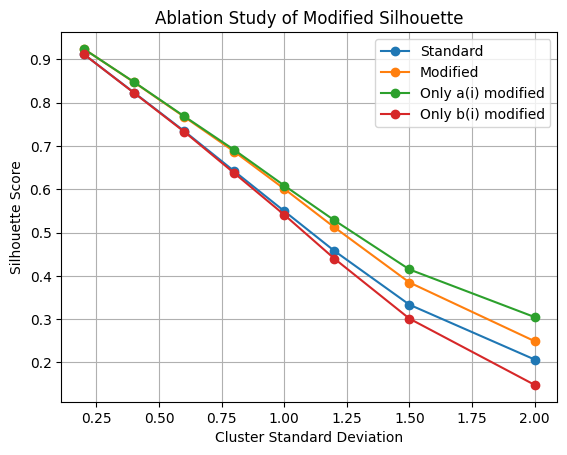

In [13]:
plt.figure()

plt.plot(df_mean["std"], df_mean["silhouette_standard"], marker='o', label="Standard")
plt.plot(df_mean["std"], df_mean["silhouette_modified"], marker='o', label="Modified")
plt.plot(df_mean["std"], df_mean["only a(i) modified"], marker='o', label="Only a(i) modified")
plt.plot(df_mean["std"], df_mean["only b(i) modified"], marker='o', label="Only b(i) modified")

plt.xlabel("Cluster Standard Deviation")
plt.ylabel("Silhouette Score")
plt.title("Ablation Study of Modified Silhouette")

plt.legend()
plt.grid()

plt.show()